<a href="https://colab.research.google.com/github/esh-g/mnist-MLP/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import numpy as np
import matplotlib.pyplot as plt

The first element of each digit in the mnist is just the number, so we need to remove that for the digit pixels and retain it for the training steps.

array([7, 2, 1, ..., 2, 4, 0])

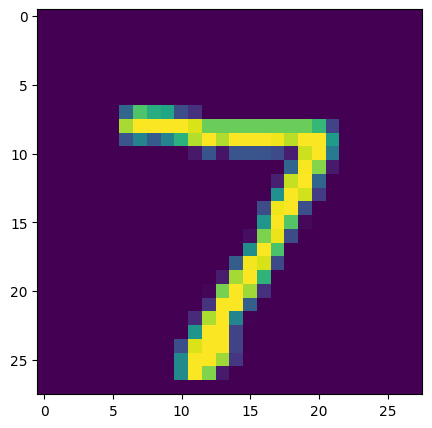

In [108]:
mnist = np.loadtxt('./sample_data/mnist_test.csv', delimiter=',')

number_of_samples = 5000

train_data = mnist[:number_of_samples]
correct_values = train_data[:, 0].astype(int)
mnist = train_data[:, 1:].astype(np.float32) / 255.0

fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(mnist[0].reshape(28, 28));
correct_values


I referred to the book "Introduction to Deep Learning" by Eugene Charniak in the BITS Library, as he mentions using the 784 -> 128 -> 10 architecture for the mnist database and the cross entropy loss.

I also watched the Welsh labs, [NN demistified series](https://youtu.be/bxe2T-V8XRs?si=ENgjXaG3VBvVy9I6)

In addition, videos by sentdex based on nnfs (neural networks from scratch were also useful in explainatins of activation functions and implementation without any libraries.)

I also got familiar with the standard notations like:

$$\begin{aligned} \text{Textbook Convention (Single Column Vector):} \quad & z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]} \\ \text{NumPy / Batch Convention (Row Vectors):} \quad & Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]} \end{aligned}$$

Where Z is the output of each layer l and A is the output from the last layer. weights and biases or layer l are W and b

# Forward Pass

In [109]:
# Neural Network layers 784 -> 128 -> 10, this was the standard structure recommended in many sources

np.random.seed(0)
weights1 = np.random.randn(784, 128) * np.sqrt(2.0 / 784) # Normalisation needed because otherwise softmax just gives one for a number and 0s for other nine, instead of smooth probs
biases1 = np.zeros((1, 128))

weights2 = np.random.randn(128, 10) * np.sqrt(1.0 / 128)
biases2 = np.zeros((1, 10))

def softmax(layer):
  shifted_z = layer - np.max(layer, axis=-1, keepdims=True) # shifted to prevent weird edge cases where e^(large number) blows up too much
  exp_z = np.exp(shifted_z)
  return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

z1 = np.ndarray((number_of_samples, 128))
a1 = np.ndarray((number_of_samples, 128))
a2 = np.ndarray((number_of_samples, 10))

def forward_pass():
  global a1, a2, z1
  # layer 1
  z1 = (mnist @ weights1) + biases1
  a1 = np.maximum(0, z1) # reLU is with np.maximum

  #layer 2
  a2 = softmax((a1 @ weights2) + biases2)

  return a2

Y_pred = forward_pass()

"""
If I have the last layer predictions as a 1x10 vector as Y. now I need dL/db(2) where b(2) is the (1x10) vector of biases for the last layer. Is that just equal to the derivative of the softmax function?
"""

#   for i in range(number_of_samples):
#     loss[i] = -np.log()

# def calculate_gradients():
#   # I'll try getting the gradients for each Weight matrix and bias vector





'\nIf I have the last layer predictions as a 1x10 vector as Y. now I need dL/db(2) where b(2) is the (1x10) vector of biases for the last layer. Is that just equal to the derivative of the softmax function?\n'


I am thinking of having separate matricies for the weights, biases and stuff
The equation looks like L = -log(y(k)) where y(k) is the softmax of the correct one hot value.



# Loss Calculation

Using the recommended cross-entropy loss

$$L = -\sum_{k=1}^n y_k \log(\hat{y}_k)$$

$y_k$ is the correct value and $\hat{y}_k$ is pred. For one hot vectors, since only one class is 1, and since the rest $y_k$ where $k$ is not equal to target, is zero, loss becomes:
  $$L = -\log(\hat{y}_c)$$

In [110]:
# categorical_cross_entropy_loss = np.zeros((number_of_samples, 1))


def compute_cross_entropy_loss():

  # We need to index only the correct class in the one hot vector, others will be automatically zero as
  # numpy allows indicing with arrays to Y_pred[[0, 1, 2], [2, 3, 4]] -> Y_pred[0, 2], Y_pred[1, 3] ...
  return -np.log(Y_pred[range(number_of_samples), correct_values] + 10e-15)
  # 10e-15 to deal with inf behaviour with zero thing


L = compute_cross_entropy_loss()

# Backpropagation

This is where the real math starts. I was able to derive the expressions for computing gradients for this sort of network and decided to store the gradients in matrices that resemble the dimensions of their respective parameters (weights and biases).

**Calculating Gradients**

In [111]:
# z = W.A + B
# dL/dz = y_pred if i != k, dL/dz = y_pred - 1 when i == k
# dL/dz = dL/db

# since differentiation is linear, differentiating each dL/db2 element will be the same as
# differntiating the sum, so we can just accumulate dL_db2 for each batch of samples.
# the math for other gradients is explained in my handwritten notes photographs
# the slight discrepancy in the notes is that here i used input layer as X, hidden layer as a1 and output as a2
# whereas in the notes, a2 was the hidden layer and a1 was the input layer

def calculate_gradients(): # this was implemented by hand and as it have a for loop, it is too slow.
  global dL_db1, dL_db2, dL_dw1, dL_dw2, da_dz

  da_dz = (z1 > 0).astype(float)
  dL_dw1 = np.zeros((784, 128))
  dL_db1 = np.zeros((1, 128))
  dL_dw2 = np.zeros((128, 10))
  dL_db2 = np.zeros((1, 10))
  error = np.zeros((1, 10))

  for i in range(number_of_samples):
      # 1. Output layer error (delta2)
      error[0] = Y_pred[i]
      error[0, correct_values[i]] -= 1  # delta2: shape (1, 10)

      # 2. Output layer gradients
      dL_db2 += error
      dL_dw2 += a1[i].reshape(128, 1) @ error

      # 3. Hidden layer error (delta1)
      delta1 = (error @ weights2.T) * da_dz[i]  # shape (1, 128)

      # 4. Hidden layer gradients
      dL_db1 += delta1
      dL_dw1 += mnist[i].reshape(784, 1) @ delta1

  # Average gradients over the batch
  dL_dw1 /= number_of_samples
  dL_db1 /= number_of_samples
  dL_dw2 /= number_of_samples
  dL_db2 /= number_of_samples


def calculate_gradients_vectorised(): # optimised numpy implementation without for loop
    global dL_db1, dL_db2, dL_dw1, dL_dw2

    # 1. Output layer error (delta2): shape (5000, 10)
    delta2 = Y_pred.copy()
    delta2[np.arange(number_of_samples), correct_values] -= 1

    # 2. Output layer gradients
    # (128, 5000) @ (5000, 10) -> (128, 10)
    dL_dw2 = (a1.T @ delta2) / number_of_samples
    dL_db2 = np.sum(delta2, axis=0, keepdims=True) / number_of_samples

    # 3. Hidden layer error (delta1): shape (5000, 128)
    # (5000, 10) @ (10, 128) * (5000, 128) -> (5000, 128)
    delta1 = (delta2 @ weights2.T) * (z1 > 0).astype(float)

    # 4. Hidden layer gradients
    # (784, 5000) @ (5000, 128) -> (784, 128)
    dL_dw1 = (mnist.T @ delta1) / number_of_samples
    dL_db1 = np.sum(delta1, axis=0, keepdims=True) / number_of_samples




**Gradient Descent**

In [119]:
steps = 1000

def update_gradients(alpha=1):
  global weights1, weights2, biases1, biases2

  weights1 += -alpha*dL_dw1
  weights2 += -alpha*dL_dw2
  biases1 += -alpha*dL_db1
  biases2 += -alpha*dL_db2

for i in range(steps):
    # 1. Forward pass (updates z1, a1, and Y_pred)
    Y_pred = forward_pass()

    # 2. Compute current loss
    loss = compute_cross_entropy_loss()
    if i % 10 == 0:
        print(f"Step {i} Mean Loss: {np.mean(loss):.4f}")

    # 3. Backward pass (computes gradients)
    calculate_gradients_vectorised()

    # 4. Optimizer step (updates weights and biases)
    update_gradients(alpha=0.1)




Step 0 Mean Loss: 0.0017
Step 10 Mean Loss: 0.0017
Step 20 Mean Loss: 0.0016
Step 30 Mean Loss: 0.0016
Step 40 Mean Loss: 0.0016
Step 50 Mean Loss: 0.0016
Step 60 Mean Loss: 0.0016
Step 70 Mean Loss: 0.0016
Step 80 Mean Loss: 0.0016
Step 90 Mean Loss: 0.0016
Step 100 Mean Loss: 0.0016
Step 110 Mean Loss: 0.0016
Step 120 Mean Loss: 0.0016
Step 130 Mean Loss: 0.0016
Step 140 Mean Loss: 0.0016
Step 150 Mean Loss: 0.0016
Step 160 Mean Loss: 0.0016
Step 170 Mean Loss: 0.0016
Step 180 Mean Loss: 0.0016
Step 190 Mean Loss: 0.0016
Step 200 Mean Loss: 0.0016
Step 210 Mean Loss: 0.0016
Step 220 Mean Loss: 0.0016
Step 230 Mean Loss: 0.0016
Step 240 Mean Loss: 0.0016
Step 250 Mean Loss: 0.0016
Step 260 Mean Loss: 0.0016
Step 270 Mean Loss: 0.0016
Step 280 Mean Loss: 0.0016
Step 290 Mean Loss: 0.0016
Step 300 Mean Loss: 0.0016
Step 310 Mean Loss: 0.0016
Step 320 Mean Loss: 0.0016
Step 330 Mean Loss: 0.0016
Step 340 Mean Loss: 0.0016
Step 350 Mean Loss: 0.0016
Step 360 Mean Loss: 0.0016
Step 370 Mea

In [120]:
# 1. Load the remaining 5,000 samples from the CSV
full_dataset = np.loadtxt('./sample_data/mnist_test.csv', delimiter=',')
test_data = full_dataset[5000:]

test_labels = test_data[:, 0].astype(int)
test_pixels = test_data[:, 1:].astype(np.float32) / 255.0

# 2. Forward pass using your trained weights and biases
z1_test = (test_pixels @ weights1) + biases1
a1_test = np.maximum(0, z1_test)
test_probs = softmax((a1_test @ weights2) + biases2)

# 3. Evaluate Predictions
test_preds = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_preds == test_labels) * 100
test_loss = -np.mean(np.log(test_probs[np.arange(len(test_labels)), test_labels] + 1e-15))

# 4. Compare with training accuracy
train_preds = np.argmax(Y_pred, axis=1)
train_acc = np.mean(train_preds == correct_values) * 100

print(f"Training Accuracy : {train_acc:.2f}% | Final Train Loss: {np.mean(loss):.4f}")
print(f"Test Accuracy     : {test_acc:.2f}% | Test Loss       : {test_loss:.4f}")

Training Accuracy : 100.00% | Final Train Loss: 0.0015
Test Accuracy     : 93.56% | Test Loss       : 0.3340
